# Zastosowanie uczenia maszynowego do wykrywania anomalii w logach auditd systemu Linux
## Zebranie logów auditd dla ruchu normalnego i scenariuszy ataku oraz ocena wybranych metod wykrywania anomalii. Projekt powinien porównywać skuteczność podejścia ML z prostą detekcją regułową.

**Autorzy:** Lukasz Kierzek, Tomasz Gondek

**Grupa:** CY2

**Specjalność:** Cyberbezpieczeństwo

**Przedmiot:** Bezpieczenstwo i hardening systemow operacyjnych

**Prowadzacy przedmiot:** mgr inz. Maryna Lukaczyk

Porownywane metody:
- Rule-based detection,
- Isolation Forest,
- Local Outlier Factor.


## 1. Przygotowanie srodowiska

In [182]:
# Path i sys sluza do poprawnego znalezienia plikow projektu z poziomu notebooka.
from pathlib import Path
import sys

# Path.cwd() zwraca folder, z ktorego uruchomiono notebook.
PROJECT_ROOT = Path.cwd()

# Jezeli notebook jest uruchomiony z folderu notebooks, cofamy sie do glownego folderu projektu.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Dodajemy folder projektu do sys.path, zeby Python widzial moduly z katalogu src.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# matplotlib rysuje wykresy, pandas tworzy tabele danych.
import matplotlib.pyplot as plt
import pandas as pd

# Sciezki do logow i etykiet sa trzymane w config.py.
from config import LABELS_PATH, RAW_LOG_PATH

# Parser laczy kilka linii auditd w jedno zdarzenie na podstawie audit_id.
from src.audit_parser import parse_lines_grouped

# Funkcja zamienia zdarzenia tekstowe na liczby, bo modele ML pracuja na liczbach.
from src.features import records_to_features

# Funkcje do wczytania etykiet i zamiany ich na serie 0/1.
from src.labels import labels_to_series, load_labels

# Wczytuje surowe linie z pliku logow.
from src.log_loader import load_logs

# Funkcje trenujace i uruchamiajace modele ML.
from src.ml_detector import (
    predict_anomalies,
    predict_local_outlier_factor,
    train_isolation_forest,
    train_local_outlier_factor,
)

# Funkcje pomocnicze do liczenia statystyk, metryk i porownan metod.
from src.preprocessing import (
    calculate_detection_statistics,
    calculate_labeled_metrics,
    compare_detection_methods,
    detections_to_dataframe,
    get_rule_anomaly_indices,
)

# Uruchamia wszystkie reguly detekcji dla kazdego zdarzenia.
from src.rules import run_all_rules_with_context

# Ustawienia wygladu wykresow.
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


In [183]:
# Wczytujemy wszystkie linie z pliku auditd_sample.log.
logs = load_logs(RAW_LOG_PATH)

# Grupujemy linie po audit_id, czyli kilka linii auditd traktujemy jako jedno zdarzenie.
records = parse_lines_grouped(logs)

# Wczytujemy plik labels.csv z informacja, ktore zdarzenia sa anomaliami.
labels_df = load_labels(LABELS_PATH)

# Tworzymy serie etykiet 0/1 o tej samej dlugosci co lista zdarzen.
y_true = labels_to_series(labels_df, len(records))

# Wypisujemy podstawowe informacje kontrolne o zbiorze danych.
print(f"Plik logow: {RAW_LOG_PATH}")
print(f"Liczba linii logu: {len([line for line in logs if line.strip()])}")
print(f"Liczba zgrupowanych zdarzen auditd: {len(records)}")
print(f"Liczba etykiet: {len(labels_df)}")


Plik logow: C:\Users\Kierzu\Documents\Cyberbezpieczeństwo sem II\Bezpieczeństwo i hardening systemów operacyjnych\projekt\data\raw\auditd_sample.log
Liczba linii logu: 2000
Liczba zgrupowanych zdarzen auditd: 514
Liczba etykiet: 514


## 2. Dane i etykiety

Etykieta `1` oznacza zdarzenie anomalne/podejrzane, a `0` oznacza zdarzenie normalne. W aktualnym zbiorze etykiety sa zgodne z generatorem `generowanie_logow.py`: `attack_activity` oraz nieudane `USER_AUTH` sa traktowane jako anomalie, a `normal_activity`, `admin_activity` i udane logowania jako zdarzenia normalne.


In [156]:
# Robimy kopie etykiet, zeby nie modyfikowac oryginalnego DataFrame.
labels_overview = labels_df.copy()

# Zamieniamy wartosci liczbowe na czytelne nazwy klas.
# 0 = normalne zdarzenie, 1 = anomalia.
labels_overview["class"] = labels_overview["label"].map({0: "normal", 1: "anomaly"})

# Pokazujemy pierwsze 10 etykiet jako szybki podglad danych.
labels_overview.head(10)


,record_index,audit_id,label,scenario,class
0,0,2,0,normal_activity,normal
1,1,3,1,attack_activity,anomaly
2,2,4,0,normal_activity,normal
3,3,5,0,admin_activity,normal
4,4,6,0,normal_activity,normal
5,5,7,0,normal_activity,normal
6,6,8,0,normal_activity,normal
7,7,9,0,normal_activity,normal
8,8,10,0,normal_activity,normal
9,9,11,0,normal_activity,normal


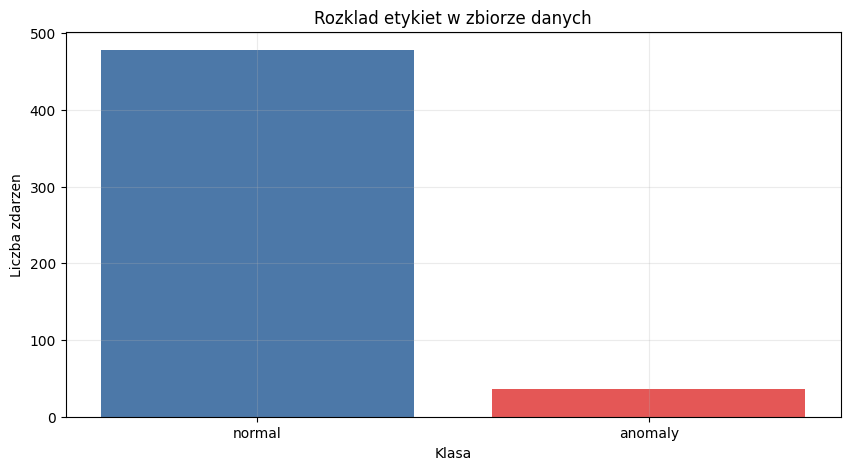

,count
class,
normal,478
anomaly,36


In [157]:
# Liczymy, ile jest zdarzen normalnych i ile anomalii.
label_counts = labels_overview["class"].value_counts().reindex(["normal", "anomaly"], fill_value=0)

# Rysujemy prosty wykres slupkowy rozkladu klas.
plt.bar(label_counts.index, label_counts.values, color=["#4c78a8", "#e45756"])
plt.title("Rozklad etykiet w zbiorze danych")
plt.xlabel("Klasa")
plt.ylabel("Liczba zdarzen")
plt.show()

# Zwracamy tez tabele z tymi samymi liczbami.
label_counts.to_frame("count")


In [158]:
# Przed oceną modeli wyznaczono podstawowe statystyki zbioru danych, takie jak liczba wszystkich zdarzeń, liczba anomalii oraz ich udział procentowy. Informacje te pozwalają określić strukturę danych wejściowych i poziom występowania incydentów bezpieczeństwa.
total = len(y_true)

anomalies = int(y_true.sum())

print(f"Dataset contains {total} events.")
print(f"Anomalies: {anomalies}")
print(f"Normal events: {total - anomalies}")
print(f"Anomaly rate: "
    f"{round(anomalies / total * 100, 2)}%")

Dataset contains 514 events.
Anomalies: 36
Normal events: 478
Anomaly rate: 7.0%


## 3. Przykladowe zgrupowane zdarzenia

Tabela ponizej pokazuje, co parser wyciaga z logow: identyfikator auditd, typ zdarzenia, uzytkownika, komende, sciezke i etykiete.

In [159]:
# Budujemy czytelna tabele zdarzen wyciagnietych przez parser.
# enumerate(records) daje jednoczesnie numer zdarzenia i sam obiekt zdarzenia.
events_df = pd.DataFrame([
    {
        "record_index": index,           # numer zdarzenia po zgrupowaniu logow
        "audit_id": record.audit_id,     # identyfikator auditd wspolny dla linii jednego zdarzenia
        "timestamp": record.timestamp,   # czas zdarzenia
        "event_type": record.event_type, # typy linii, np. SYSCALL, EXECVE, CWD, PATH
        "uid": record.user_id,           # efektywny uzytkownik wykonujacy akcje
        "auid": record.audit_user_id,    # uzytkownik zalogowany na poczatku sesji
        "command": record.command,       # wykonana komenda
        "executable": record.executable, # sciezka do programu
        "path": record.path,             # sciezka pliku, ktorego dotyczylo zdarzenie
        "success": record.success,       # True/False, czy operacja sie udala
        "label": int(y_true.iloc[index]),# etykieta 0/1 dla tego zdarzenia
    }
    for index, record in enumerate(records)
])

# Pokazujemy pierwsze 12 zdarzen.
events_df.head(12)


,record_index,audit_id,timestamp,event_type,uid,auid,command,executable,path,success,label
0,0,2,2024-05-14 11:15:06.000,"SYSCALL,EXECVE,CWD,PATH",1000,1000,vim,/usr/bin/vim,/etc/hosts,True,0
1,1,3,2024-05-14 11:15:20.727,"SYSCALL,EXECVE,CWD,PATH",1000,1000,sudo,/usr/bin/sudo,/etc/shadow,True,1
2,2,4,2024-05-14 11:15:22.110,"SYSCALL,EXECVE,CWD,PATH",1000,1000,git,/usr/bin/git,/home/lukasz/.bashrc,True,0
3,3,5,2024-05-14 11:15:44.290,"SYSCALL,EXECVE,CWD,PATH",1000,1000,systemctl,/usr/bin/systemctl,/home/lukasz/file.txt,True,0
4,4,6,2024-05-14 11:16:17.861,"SYSCALL,EXECVE,CWD,PATH",1000,1000,cat,/usr/bin/cat,/home/lukasz/.bashrc,False,0
5,5,7,2024-05-14 11:17:09.983,"SYSCALL,EXECVE,CWD,PATH",1000,1000,curl,/usr/bin/curl,/home/lukasz/projects/app.py,True,0
6,6,8,2024-05-14 11:17:26.735,"SYSCALL,EXECVE,CWD,PATH",1000,1000,nano,/usr/bin/nano,/home/lukasz/.bashrc,True,0
7,7,9,2024-05-14 11:18:00.595,"SYSCALL,EXECVE,CWD,PATH",1000,1000,nano,/usr/bin/nano,/etc/hosts,True,0
8,8,10,2024-05-14 11:18:57.227,"SYSCALL,EXECVE,CWD,PATH",1000,1000,curl,/usr/bin/curl,/home/lukasz/projects/app.py,True,0
9,9,11,2024-05-14 11:19:31.347,"SYSCALL,EXECVE,CWD,PATH",1000,1000,ssh,/usr/bin/ssh,/etc/hosts,True,0


## 4. Detekcja regulowa

Reguly sa czytelne i latwe do wyjasnienia. W projekcie wykrywaja m.in. podejrzane komendy, aktywnosc roota, nieudane operacje, nietypowe godziny, nietypowe UID, narzedzia administracyjne i podejrzane sciezki.

In [160]:
# Uruchamiamy wszystkie reguly dla kazdego zdarzenia.
detections_by_record = run_all_rules_with_context(records)

# Liczymy zbiorcze statystyki: ile zdarzen reguly uznaly za anomalie.
stats = calculate_detection_statistics(records)

# Zamieniamy pojedyncze wykrycia regul na tabele, zeby latwo je pokazac.
detections_df = detections_to_dataframe(records)

# Tworzymy podsumowanie w formie tabeli.
summary_df = pd.DataFrame([
    {"metric": "total_events", "value": stats["total_logs"]},
    {"metric": "rule_anomalies", "value": stats["anomaly_logs"]},
    {"metric": "rule_normal", "value": stats["normal_logs"]},
    {
        "metric": "rule_anomaly_percentage",
        # Procent zdarzen oznaczonych przez reguly jako anomalie.
        "value": round(stats["anomaly_logs"] / stats["total_logs"] * 100, 2) if stats["total_logs"] else 0,
    },
])
summary_df


,metric,value
0,total_events,514.00
1,rule_anomalies,237.00
2,rule_normal,277.00
3,rule_anomaly_percentage,46.11


In [161]:
# Liczymy, ktore reguly odpalaly sie najczesciej.
rule_summary = (
    detections_df["rule"]              # wybieramy kolumne z nazwa reguly
    .value_counts()                    # zliczamy wystapienia kazdej reguly
    .rename_axis("rule")              # nadajemy nazwe indeksowi
    .reset_index(name="detections")   # zamieniamy wynik na zwykla tabele
)
rule_summary


,rule,detections
0,Night Activity,121
1,Unknown Command,83
2,Failed Command,32
3,Administrative Tool,29
4,Suspicious Executable Path,20
5,Root Activity,18
6,Unusual UID,18
7,Suspicious Command,16
8,Unusual Event Combination,15


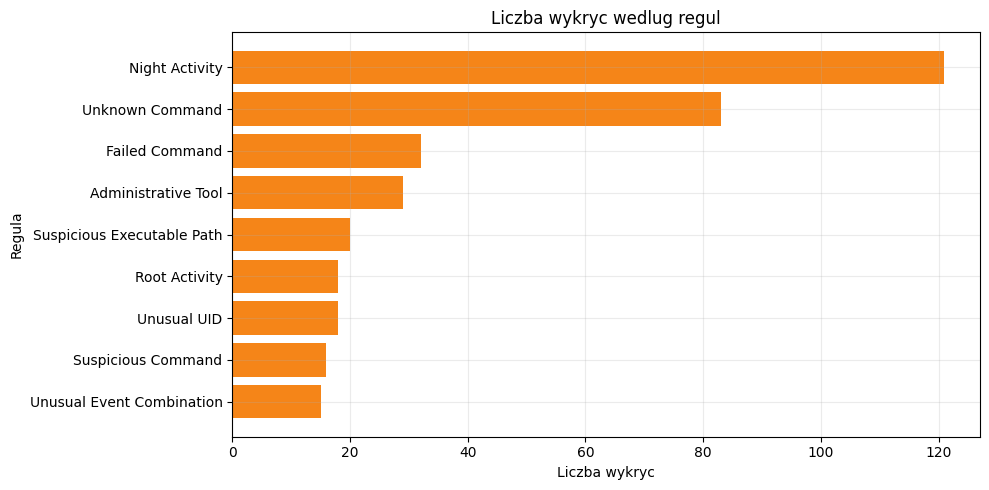

In [162]:
# Jezeli sa jakiekolwiek wykrycia, rysujemy ranking regul.
if not rule_summary.empty:
    plt.barh(rule_summary["rule"], rule_summary["detections"], color="#f58518")
    plt.title("Liczba wykryc wedlug regul")
    plt.xlabel("Liczba wykryc")
    plt.ylabel("Regula")
    plt.gca().invert_yaxis()  # najwieksza wartosc bedzie na gorze wykresu
    plt.tight_layout()        # dopasowuje marginesy, zeby etykiety sie nie ucinaly
    plt.show()


In [163]:
# Pokazujemy pierwsze konkretne alarmy regulowe.
# Ta tabela pomaga powiedziec: jaka komenda, jaki uzytkownik i ktora regula zadzialala.
detections_df.head(15)


,timestamp,command,user_id,rule,reason
0,2024-05-14 11:15:20.727,sudo,1000,Administrative Tool,Administrative tool executed: sudo
1,2024-05-14 11:15:22.110,git,1000,Unknown Command,Unknown command detected: git
2,2024-05-14 11:15:44.290,systemctl,1000,Administrative Tool,Administrative tool executed: systemctl
3,2024-05-14 11:16:17.861,cat,1000,Failed Command,Command execution failed
4,2024-05-14 11:19:38.817,NaN,0,Root Activity,Root user activity detected
5,2024-05-14 11:19:38.817,NaN,0,Unusual UID,Root effective UID with non-root auid: auid=1000
6,2024-05-14 11:21:47.071,systemctl,1000,Administrative Tool,Administrative tool executed: systemctl
7,2024-05-14 11:21:52.154,NaN,0,Root Activity,Root user activity detected
8,2024-05-14 11:21:52.154,NaN,0,Failed Command,Command execution failed
9,2024-05-14 11:21:52.154,NaN,0,Unusual UID,Root effective UID with non-root auid: auid=1000


## 5. Feature engineering

Modele ML dostaja cechy liczbowe opisujace zdarzenie. Przyklady: godzina, aktywnosc roota, sukces operacji, nietypowa sciezka, komenda administracyjna, roznica `uid`/`auid` oraz dlugosc komunikatu logu.

In [164]:
# Feature engineering: zamiana zdarzen auditd na cechy liczbowe.
# ML nie rozumie tekstu typu "sudo" albo "/tmp/backdoor.sh" bez takiej zamiany.
features_df = records_to_features(records)

# Pokazujemy pierwsze wiersze cech, ktore trafia do modeli ML.
features_df.head()


,hour,is_root,success,is_night,is_suspicious_command,is_admin_tool,is_unknown_command,has_executable,has_path,has_suspicious_path,uid,auid,uid_mismatch,event_type_code,command_length,raw_message_length
0,11,0,1,0,0,0,0,1,1,0,1000,1000,0,42,3,377
1,11,0,1,0,0,1,0,1,1,0,1000,1000,0,42,4,410
2,11,0,1,0,0,0,0,1,1,0,1000,1000,0,42,3,396
3,11,0,1,0,0,1,0,1,1,0,1000,1000,0,42,9,391
4,11,0,0,0,0,0,0,1,1,0,1000,1000,0,42,3,397


In [165]:
# describe() liczy statystyki opisowe dla kazdej cechy.
# T oznacza transpozycje, czyli cechy sa w wierszach, a statystyki w kolumnach.
feature_summary = features_df.describe().T[["mean", "std", "min", "max"]].round(2)
feature_summary


,mean,std,min,max
hour,9.49,6.53,0.0,21.0
is_root,0.04,0.18,0.0,1.0
success,0.94,0.24,0.0,1.0
is_night,0.24,0.42,0.0,1.0
is_suspicious_command,0.03,0.17,0.0,1.0
is_admin_tool,0.06,0.23,0.0,1.0
is_unknown_command,0.04,0.18,0.0,1.0
has_executable,1.00,0.00,1.0,1.0
has_path,0.96,0.19,0.0,1.0
has_suspicious_path,0.04,0.19,0.0,1.0


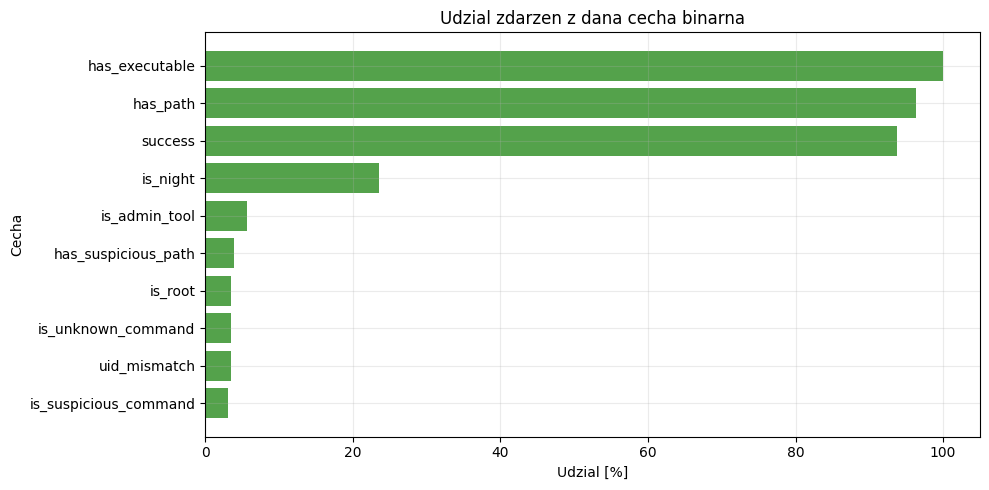

In [166]:
# Wybieramy cechy binarne, czyli takie, ktore maja wartosc 0 albo 1.
binary_features = [
    "is_root",
    "success",
    "is_night",
    "is_suspicious_command",
    "is_admin_tool",
    "is_unknown_command",
    "has_executable",
    "has_path",
    "has_suspicious_path",
    "uid_mismatch",
]

# Srednia z kolumny 0/1 oznacza odsetek zdarzen, gdzie cecha ma wartosc 1.
# Mnozymy przez 100, zeby dostac procenty.
binary_rates = features_df[binary_features].mean().sort_values(ascending=False) * 100

# Rysujemy udzial procentowy kazdej cechy binarnej.
plt.barh(binary_rates.index, binary_rates.values, color="#54a24b")
plt.title("Udzial zdarzen z dana cecha binarna")
plt.xlabel("Udzial [%]")
plt.ylabel("Cecha")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Modele ML

Uzyte modele sa **nienadzorowane**, czyli nie wymagaja etykiet podczas treningu. Model widzi tylko cechy liczbowe i sam szuka punktow, ktore wygladaja nietypowo na tle reszty.

**Isolation Forest** buduje wiele losowych drzew. Zdarzenia latwe do odizolowania od reszty sa traktowane jako bardziej podejrzane.

**Local Outlier Factor** porownuje gestosc sasiedztwa. Jezeli zdarzenie ma wokol siebie malo podobnych zdarzen, moze zostac uznane za odstajace.

Wazne: etykiety z `labels.csv` nie ucza tych modeli. Etykiety sa uzyte dopiero pozniej, zeby sprawdzic, czy wykrycia byly trafne.


In [167]:
# Trenujemy Isolation Forest na wszystkich cechach.
# To model nienadzorowany: podczas treningu nie dostaje etykiet 0/1.
isolation_model = train_isolation_forest(features_df)

# Model zwraca 1 dla normalnych punktow i -1 dla anomalii.
isolation_predictions = predict_anomalies(isolation_model, features_df)

# Trenujemy Local Outlier Factor, drugi model nienadzorowany.
lof_model = train_local_outlier_factor(features_df)

# Tak samo: 1 oznacza normalne zdarzenie, -1 oznacza anomalie.
lof_predictions = predict_local_outlier_factor(lof_model, features_df)

# Zbieramy indeksy zdarzen, ktore reguly oznaczyly jako anomalie.
rule_indices = get_rule_anomaly_indices(records)

# Zbieramy indeksy zdarzen, ktore Isolation Forest oznaczyl jako anomalie.
isolation_indices = {index for index, value in enumerate(isolation_predictions) if value == -1}

# Zbieramy indeksy zdarzen, ktore LOF oznaczyl jako anomalie.
lof_indices = {index for index, value in enumerate(lof_predictions) if value == -1}

# Wypisujemy, ile alarmow wygenerowala kazda metoda.
print(f"Rule-based anomalies: {len(rule_indices)}")
print(f"Isolation Forest anomalies: {len(isolation_indices)}")
print(f"Local Outlier Factor anomalies: {len(lof_indices)}")


Rule-based anomalies: 237
Isolation Forest anomalies: 26
Local Outlier Factor anomalies: 13


## 7. Porownanie liczby wykrytych anomalii

Ten wykres pokazuje, ile zdarzen kazda metoda oznaczyla jako anomalie. Sama liczba wykryc nie oznacza jeszcze skutecznosci, dlatego w kolejnej sekcji liczymy metryki na etykietach.

In [168]:
# Tworzymy tabele porownujaca liczbe wykrytych anomalii przez kazda metode.
# overlap_with_rules pokazuje, ile wykryc ML pokrywa sie z detekcja regulowa.
comparison_df = compare_detection_methods(records, isolation_predictions, lof_predictions)
comparison_df


,method,detected_anomalies,percentage,overlap_with_rules
0,Rule-based,237,46.11,237
1,Isolation Forest,26,5.06,26
2,Local Outlier Factor,13,2.53,12


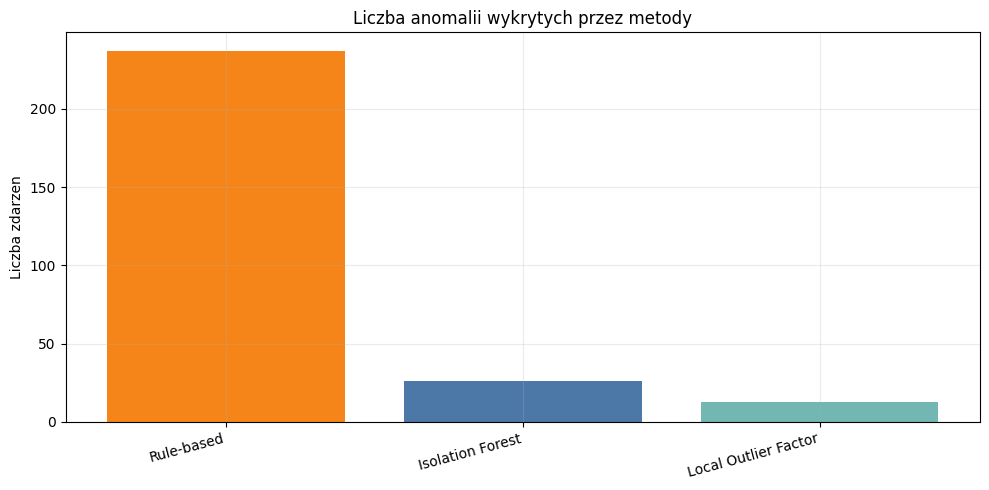

In [169]:
# Rysujemy liczbe zdarzen oznaczonych jako anomalie przez kazda metode.
plt.bar(comparison_df["method"], comparison_df["detected_anomalies"], color=["#f58518", "#4c78a8", "#72b7b2"])
plt.title("Liczba anomalii wykrytych przez metody")
plt.ylabel("Liczba zdarzen")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 8. Ocena na danych oznaczonych

Dzieki `data/labels.csv` mozemy policzyc metryki jakosci:
- **accuracy**: ogolna trafnosc, ale przy niezbalansowanych danych moze byc mylaca,
- **precision**: z alarmow wygenerowanych przez metode, ile bylo faktycznymi anomaliami,
- **recall**: z prawdziwych anomalii, ile metoda wykryla,
- **F1**: kompromis miedzy precision i recall.

Przy cyberbezpieczenstwie recall jest wazny, bo pokazuje, czy metoda nie pomija atakow. Precision tez jest wazne, bo niskie precision oznacza duzo falszywych alarmow.


In [170]:
# Liczymy metryki jakosci, porownujac predykcje metod z etykietami z labels.csv.
# To jest moment, w ktorym etykiety sa uzywane do oceny, a nie do treningu modeli ML.
labeled_metrics_df = calculate_labeled_metrics(
    records,
    y_true,
    isolation_predictions,
    lof_predictions,
)
labeled_metrics_df


,method,tp,fp,tn,fn,accuracy,precision,recall,f1
0,Rule-based,36,201,277,0,60.89,15.19,100.00,26.37
1,Isolation Forest,16,10,468,20,94.16,61.54,44.44,51.61
2,Local Outlier Factor,4,9,469,32,92.02,30.77,11.11,16.33


In [171]:
# Ranking metod
labeled_metrics_df.sort_values(
    "f1",
    ascending=False
)

,method,tp,fp,tn,fn,accuracy,precision,recall,f1
1,Isolation Forest,16,10,468,20,94.16,61.54,44.44,51.61
0,Rule-based,36,201,277,0,60.89,15.19,100.00,26.37
2,Local Outlier Factor,4,9,469,32,92.02,30.77,11.11,16.33


In [172]:
labeled_metrics_df[
    [
        "method",
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
]

,method,accuracy,precision,recall,f1
0,Rule-based,60.89,15.19,100.00,26.37
1,Isolation Forest,94.16,61.54,44.44,51.61
2,Local Outlier Factor,92.02,30.77,11.11,16.33


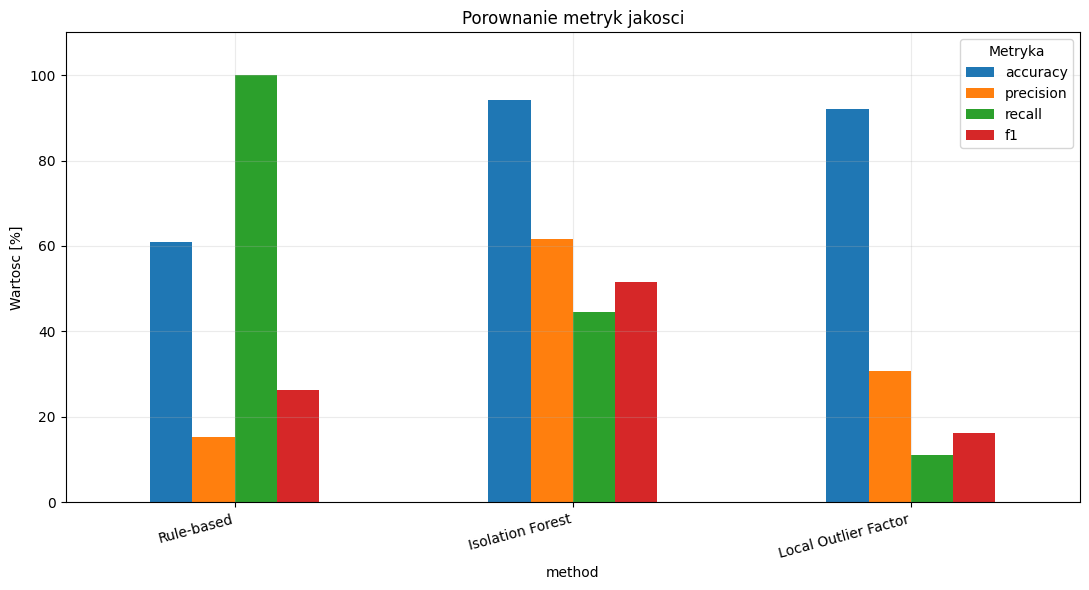

In [173]:
# Wybieramy metryki, ktore chcemy pokazac na wykresie.
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]

# Ustawiamy nazwe metody jako indeks, zeby pandas latwo narysowal wykres slupkowy.
plot_df = labeled_metrics_df.set_index("method")[metrics_to_plot]

# Rysujemy porownanie metryk dla metod.
ax = plot_df.plot(kind="bar", figsize=(11, 6))
plt.title("Porownanie metryk jakosci")
plt.ylabel("Wartosc [%]")
plt.ylim(0, 110)
plt.xticks(rotation=15, ha="right")
plt.legend(title="Metryka")
plt.tight_layout()
plt.show()


In [174]:
# Sortujemy metryki, zeby znalezc najlepsza metode wedlug F1.
best_f1 = labeled_metrics_df.sort_values("f1", ascending=False).iloc[0]

# Sortujemy metryki, zeby znalezc najlepsza metode wedlug recall.
best_recall = labeled_metrics_df.sort_values("recall", ascending=False).iloc[0]

# Sortujemy metryki, zeby znalezc najlepsza metode wedlug precision.
best_precision = labeled_metrics_df.sort_values("precision", ascending=False).iloc[0]

# Pokazujemy zwyciezcow dla trzech roznych kryteriow.
pd.DataFrame([
    {"criterion": "best_f1", "method": best_f1["method"], "value": best_f1["f1"]},
    {"criterion": "best_recall", "method": best_recall["method"], "value": best_recall["recall"]},
    {"criterion": "best_precision", "method": best_precision["method"], "value": best_precision["precision"]},
])


,criterion,method,value
0,best_f1,Isolation Forest,51.61
1,best_recall,Rule-based,100.00
2,best_precision,Isolation Forest,61.54


## 9. Macierze pomylek

Macierz pomylek pokazuje konkretne bledy:
- `TP`: poprawnie wykryte anomalie,
- `FP`: normalne zdarzenia oznaczone jako anomalie,
- `TN`: poprawnie wykryte normalne zdarzenia,
- `FN`: anomalie przeoczone przez metode.

In [175]:
# melt zamienia szeroka tabele metryk na dluga forme: metoda, typ bledu, liczba.
confusion_long = labeled_metrics_df[["method", "tp", "fp", "tn", "fn"]].melt(
    id_vars="method",
    var_name="type",
    value_name="count",
)

# pivot uklada dane z powrotem jako czytelna tabele macierzy pomylek.
pivot_confusion = confusion_long.pivot(index="method", columns="type", values="count")[["tp", "fp", "tn", "fn"]]
pivot_confusion


type,tp,fp,tn,fn
method,,,,
Isolation Forest,16,10,468,20
Local Outlier Factor,4,9,469,32
Rule-based,36,201,277,0


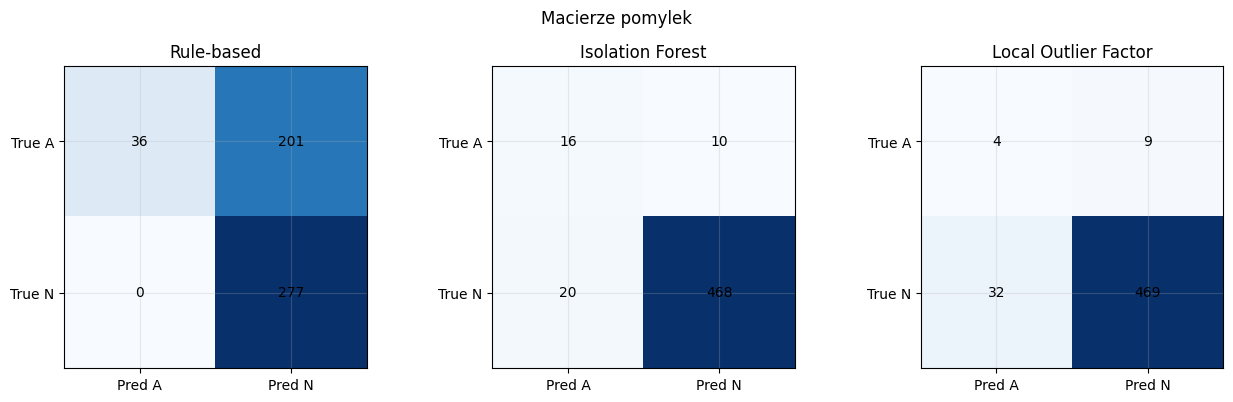

In [176]:
# Tworzymy jeden wykres dla kazdej metody.
fig, axes = plt.subplots(1, len(labeled_metrics_df), figsize=(13, 4))

# Iterujemy jednoczesnie po osiach wykresu i wierszach tabeli metryk.
for ax, row in zip(axes, labeled_metrics_df.itertuples(index=False)):
    # Macierz: pierwszy wiersz to prawdziwe anomalie, drugi to prawdziwe normalne.
    matrix = [[row.tp, row.fp], [row.fn, row.tn]]

    # imshow rysuje macierz jako obraz kolorow.
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(row.method)
    ax.set_xticks([0, 1], labels=["Pred A", "Pred N"])
    ax.set_yticks([0, 1], labels=["True A", "True N"])

    # Wpisujemy liczby do srodka kazdego pola macierzy.
    for y in range(2):
        for x in range(2):
            ax.text(x, y, matrix[y][x], ha="center", va="center", color="black")

fig.suptitle("Macierze pomylek")
plt.tight_layout()
plt.show()


## 10. Czesc wspolna wykryc

Porownujemy, ktore zdarzenia zostaly wykryte tylko przez jedna metode, a ktore przez wszystkie. To pomaga pokazac, ze reguly i ML moga wskazywac inne typy nietypowych zachowan.

In [177]:
# Porownujemy zbiory indeksow wykrytych anomalii.
# Operator - oznacza roznice zbiorow, a & oznacza czesc wspolna.
overlap_df = pd.DataFrame([
    {"category": "Rule only", "count": len(rule_indices - isolation_indices - lof_indices)},
    {"category": "Isolation only", "count": len(isolation_indices - rule_indices - lof_indices)},
    {"category": "LOF only", "count": len(lof_indices - rule_indices - isolation_indices)},
    {"category": "Rule + Isolation", "count": len((rule_indices & isolation_indices) - lof_indices)},
    {"category": "Rule + LOF", "count": len((rule_indices & lof_indices) - isolation_indices)},
    {"category": "Isolation + LOF", "count": len((isolation_indices & lof_indices) - rule_indices)},
    {"category": "All methods", "count": len(rule_indices & isolation_indices & lof_indices)},
])
overlap_df


,category,count
0,Rule only,201
1,Isolation only,0
2,LOF only,1
3,Rule + Isolation,24
4,Rule + LOF,10
5,Isolation + LOF,0
6,All methods,2


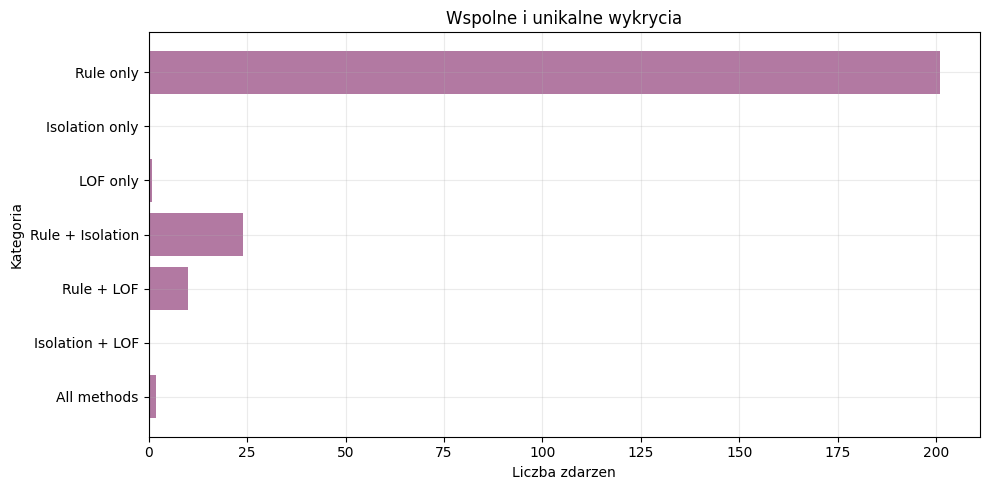

In [178]:
# Rysujemy, ile wykryc bylo unikalnych dla jednej metody albo wspolnych dla kilku.
plt.barh(overlap_df["category"], overlap_df["count"], color="#b279a2")
plt.title("Wspolne i unikalne wykrycia")
plt.xlabel("Liczba zdarzen")
plt.ylabel("Kategoria")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 11. Szczegoly wykryc metod

Tabela laczy etykiety, dane zdarzenia i decyzje kazdej metody. To najbardziej praktyczny widok do omawiania konkretnych przypadkow.

In [179]:
# Kopiujemy tabele zdarzen i dokladamy decyzje kazdej metody.
method_decisions_df = events_df.copy()

# Zamieniamy etykiete 0/1 na nazwe klasy dla czytelnosci.
method_decisions_df["label_name"] = method_decisions_df["label"].map({0: "normal", 1: "anomaly"})

# True oznacza, ze dana metoda wykryla anomalie dla danego indeksu zdarzenia.
method_decisions_df["rule_based"] = [index in rule_indices for index in range(len(records))]
method_decisions_df["isolation_forest"] = [index in isolation_indices for index in range(len(records))]
method_decisions_df["local_outlier_factor"] = [index in lof_indices for index in range(len(records))]

# Dodajemy opis scenariusza z labels.csv, np. attack_activity albo normal_activity.
method_decisions_df["scenario"] = labels_df.set_index("record_index").reindex(range(len(records)))["scenario"].values

# Pokazujemy najwazniejsze kolumny do omawiania konkretnych zdarzen.
method_decisions_df[[
    "record_index",
    "audit_id",
    "scenario",
    "label_name",
    "command",
    "uid",
    "auid",
    "success",
    "rule_based",
    "isolation_forest",
    "local_outlier_factor",
]].head(20)


,record_index,audit_id,scenario,label_name,command,uid,auid,success,rule_based,isolation_forest,local_outlier_factor
0,0,2,normal_activity,normal,vim,1000,1000,True,False,False,False
1,1,3,attack_activity,anomaly,sudo,1000,1000,True,True,False,False
2,2,4,normal_activity,normal,git,1000,1000,True,True,False,False
3,3,5,admin_activity,normal,systemctl,1000,1000,True,True,False,False
4,4,6,normal_activity,normal,cat,1000,1000,False,True,False,False
5,5,7,normal_activity,normal,curl,1000,1000,True,False,False,False
6,6,8,normal_activity,normal,nano,1000,1000,True,False,False,False
7,7,9,normal_activity,normal,nano,1000,1000,True,False,False,False
8,8,10,normal_activity,normal,curl,1000,1000,True,False,False,False
9,9,11,normal_activity,normal,ssh,1000,1000,True,False,False,False


In [180]:
# Szukamy anomalii z etykiet, ktorych nie wykryla zadna metoda.
# To sa najciekawsze przypadki false negative z punktu widzenia calego systemu.
missed_anomalies = method_decisions_df[
    (method_decisions_df["label"] == 1)
    & ~method_decisions_df["rule_based"]
    & ~method_decisions_df["isolation_forest"]
    & ~method_decisions_df["local_outlier_factor"]
]

# Pokazujemy tylko najwazniejsze kolumny tych pominietych anomalii.
missed_anomalies[["record_index", "scenario", "command", "uid", "success"]]


,record_index,scenario,command,uid,success


## 12. Automatyczne podsumowanie wynikow

In [181]:
print("Podsumowanie projektu")

print(f"Liczba zgrupowanych zdarzen auditd: {len(records)}")
print(f"Liczba anomalii wedlug etykiet: {int(y_true.sum())}")
print(f"Liczba zdarzen normalnych wedlug etykiet: {len(y_true) - int(y_true.sum())}")

print()

for row in labeled_metrics_df.itertuples(index=False):
    print(f"{row.method}: F1={row.f1}%,"
          f" precision={row.precision}%,"
          f" recall={row.recall}%,"
          f" TP={row.tp},"
          f" FP={row.fp},"
          f" TN={row.tn},"
          f" FN={row.fn}")

print()

best_f1 = labeled_metrics_df.sort_values("f1", ascending=False).iloc[0]
best_precision = labeled_metrics_df.sort_values("precision", ascending=False).iloc[0]
best_recall = labeled_metrics_df.sort_values("recall", ascending=False).iloc[0]

print(f"Najwyzszy wynik F1 uzyskala metoda {best_f1['method']} ({best_f1['f1']}%).")
print(f"Najwyzsza precision zostala uzyskana przez {best_precision['method']} ({best_precision['precision']}%).")
print(f"Najwyzszy recall zostal uzyskany przez {best_recall['method']} ({best_recall['recall']}%).")

print()

print("Wyniki pokazuja, ze rozne metody wykrywania anomalii charakteryzuja sie odmiennym kompromisem pomiedzy precision i recall.")
print("Detekcja regulowa wykorzystuje jawnie zdefiniowane reguly, natomiast Isolation Forest i LOF wykrywaja odstajace zachowania na podstawie cech danych.")

print()

print("Ograniczenie: dane wykorzystane w projekcie sa syntetyczne, dlatego wyniki nalezy traktowac jako porownanie metod w kontrolowanym scenariuszu testowym, a nie jako rzeczywista skutecznosc produkcyjna.")

Podsumowanie projektu
Liczba zgrupowanych zdarzen auditd: 514
Liczba anomalii wedlug etykiet: 36
Liczba zdarzen normalnych wedlug etykiet: 478

Rule-based: F1=26.37%, precision=15.19%, recall=100.0%, TP=36, FP=201, TN=277, FN=0
Isolation Forest: F1=51.61%, precision=61.54%, recall=44.44%, TP=16, FP=10, TN=468, FN=20
Local Outlier Factor: F1=16.33%, precision=30.77%, recall=11.11%, TP=4, FP=9, TN=469, FN=32

Najwyzszy wynik F1 uzyskala metoda Isolation Forest (51.61%).
Najwyzsza precision zostala uzyskana przez Isolation Forest (61.54%).
Najwyzszy recall zostal uzyskany przez Rule-based (100.0%).

Wyniki pokazuja, ze rozne metody wykrywania anomalii charakteryzuja sie odmiennym kompromisem pomiedzy precision i recall.
Detekcja regulowa wykorzystuje jawnie zdefiniowane reguly, natomiast Isolation Forest i LOF wykrywaja odstajace zachowania na podstawie cech danych.

Ograniczenie: dane wykorzystane w projekcie sa syntetyczne, dlatego wyniki nalezy traktowac jako porownanie metod w kontrol

## 13. Wnioski koncowe

- Detekcja regulowa uzyskala najwyzszy recall, ale generowala wiecej falszywych alarmow.
- Isolation Forest osiagnal najlepszy wynik F1, zachowujac dobry kompromis pomiedzy precision i recall.
- Local Outlier Factor wykryl najmniej anomalii w analizowanym zbiorze.
- Metody ML i detekcja regulowa wykrywaly czesciowo rozne zdarzenia, dlatego moga sie wzajemnie uzupelniac.
- Wyniki zostaly uzyskane na syntetycznych logach auditd i powinny byc traktowane jako porownanie metod, a nie ich rzeczywista skutecznosc w systemie produkcyjnym.